This notebook is to display and compare the results I personally conducted and the results found by the paper. This is to make sure what we're getting is correct!

## Import libraries

In [1]:
import matplotlib.pyplot as plt
import math

In [2]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [3]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

In [51]:
def plotResults( experiments, labels, xLabel, yLabel, titles, ylim = 100, numRow = 2, figsize = (6,4), suptitle=""):

    numCol = math.ceil( len( experiments ) / numRow )
    fig, axs = plt.subplots(numRow, numCol, sharey=True, figsize=figsize)#figsize=(6, 4))
    plotInd = 0
    for X, plots in experiments:
        X_int = [int(x) for x in X]
        r, c = plotInd // numCol, plotInd % numCol

        for i in range(len( plots ) ):
            axs[r,c].plot(X_int, plots[i], label=labels[i] )
        axs[r,c].set_title(titles[plotInd])
        axs[r,c].grid()
        axs[r,c].set_ylim(bottom = 0,top=ylim)
        if( plotInd == numCol - 1 ):
            leg = axs[r,c].legend(loc="upper left", bbox_to_anchor=(1, 1))
            #leg.set_in_layout(False)
        axs[r,c].locator_params(nbins=4)
        
        plotInd += 1
    while( plotInd < numCol * numRow ):
        r, c = plotInd // numCol, plotInd % numCol
        axs[r,c].axis("off")
        plotInd += 1
    
    for ax in axs.flat:
        ax.set(xlabel=xLabel, ylabel=yLabel)

    if( suptitle ):
        fig.suptitle(suptitle, fontsize=14)

    
    fig.tight_layout()

    plt.savefig( f"{suptitle}.png" ) 

# Replicating MuCache Results

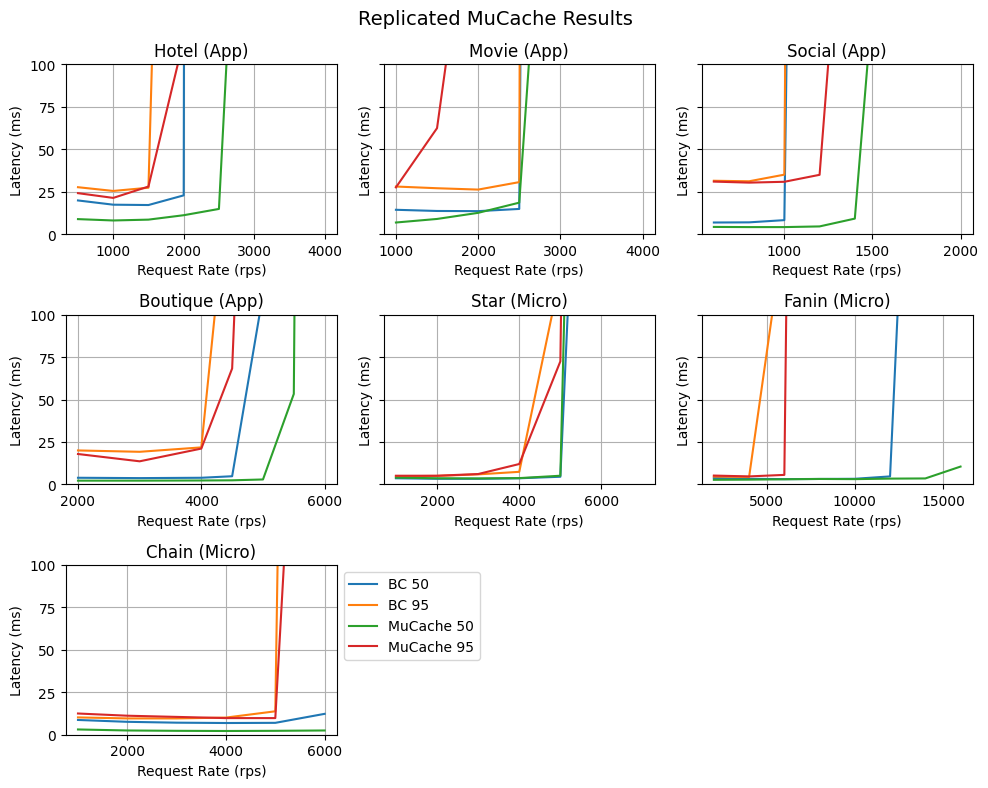

In [45]:
# Run all benchmarks
hotel_x, hotel_bc = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq.json" )
_, hotel_mucache = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq.json" )
movie_x, movie_bc = getStats( "movie-baseline-5000app-12proxy-1zmq.json" )
_, movie_mucache = getStats( "movie-5000app-12proxy-1zmq.json" )
social_x, social_bc = getStats( "social-baseline-5000app-12proxy-1zmq.json" )
_, social_mucache = getStats( "social-5000app-12proxy-1zmq.json" )
boutique_x, boutique_bc = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq.json" )
_, boutique_mucache = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq.json" )
star_x, star_bc = getStats( "star-baseline-5000app-12proxy-1zmq.json" )
_, star_mucache = getStats( "star-5000app-12proxy-1zmq.json" )
fanin_x, fanin_bc = getStats( "fanin-baseline-5000app-12proxy-1zmq.json" )
_, fanin_mucache = getStats( "fanin-5000app-12proxy-1zmq.json" )
chain_x, chain_bc = getStats( "chain-baseline-5000app-12proxy-1zmq.json" )
_, chain_mucache = getStats( "chain-5000app-12proxy-1zmq.json" )


experiments = [(hotel_x, [hotel_bc["50"], hotel_bc["95"], hotel_mucache["50"], hotel_mucache["95"]]), 
               (movie_x, [movie_bc["50"], movie_bc["95"], movie_mucache["50"], movie_mucache["95"]]), 
               (social_x, [social_bc["50"], social_bc["95"], social_mucache["50"], social_mucache["95"]]), 
               (boutique_x, [boutique_bc["50"], boutique_bc["95"], boutique_mucache["50"], boutique_mucache["95"]]),
               (star_x, [star_bc["50"], star_bc["95"], star_mucache["50"], star_mucache["95"]]),
               (fanin_x, [fanin_bc["50"], fanin_bc["95"], fanin_mucache["50"], fanin_mucache["95"]]),
               (chain_x, [chain_bc["50"], chain_bc["95"], chain_mucache["50"], chain_mucache["95"]])
              ]
labels = ["BC 50", "BC 95", "MuCache 50", "MuCache 95"]
titles = ["Hotel (App)", "Movie (App)", "Social (App)", "Boutique (App)", "Star (Micro)", "Fanin (Micro)", "Chain (Micro)"]

plotResults( experiments, labels, "Request Rate (rps)", "Latency (ms)", titles, numRow = 3, figsize=(10,8), suptitle = "Replicated MuCache Results" )


# Batch Invalidation Results

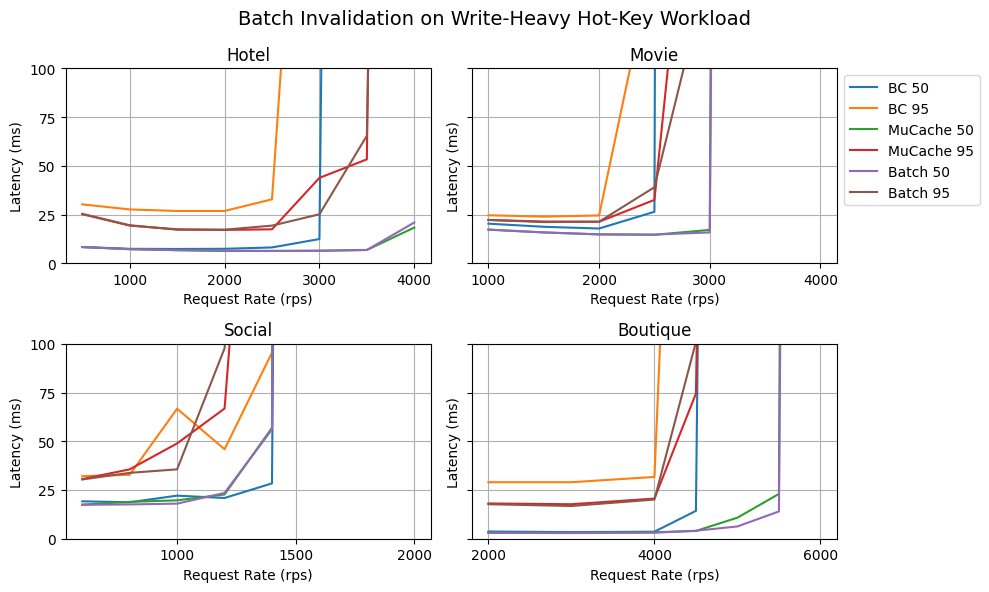

In [13]:
# Write Heavy Hot Key Workload
hotel_x, hotel_bc = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, hotel_mucache = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, hotel_batch = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
movie_x, movie_bc = getStats( "movie-baseline-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, movie_mucache = getStats( "movie-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, movie_batch = getStats( "movie-batch-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
social_x, social_bc = getStats( "social-baseline-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, social_mucache = getStats( "social-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, social_batch = getStats( "social-batch-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
boutique_x, boutique_bc = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, boutique_mucache = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, boutique_batch = getStats( "boutique-batch-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )

experiments = [(hotel_x, [hotel_bc["50"], hotel_bc["95"], hotel_mucache["50"], hotel_mucache["95"], hotel_batch["50"], hotel_batch["95"]]), 
               (movie_x, [movie_bc["50"], movie_bc["95"], movie_mucache["50"], movie_mucache["95"], movie_batch["50"], movie_batch["95"]]), 
               (social_x, [social_bc["50"], social_bc["95"], social_mucache["50"], social_mucache["95"], social_batch["50"], social_batch["95"]]), 
               (boutique_x, [boutique_bc["50"], boutique_bc["95"], boutique_mucache["50"], boutique_mucache["95"], boutique_batch["50"], boutique_batch["95"]]),
              ]
labels = ["BC 50", "BC 95", "MuCache 50", "MuCache 95", "Batch 50", "Batch 95"]
titles = ["Hotel", "Movie", "Social", "Boutique"]

plotResults( experiments, labels, "Request Rate (rps)", "Latency (ms)", titles, numRow = 2, figsize=(10,6), suptitle = "Batch Invalidation on Write-Heavy Hot-Key Workload" )


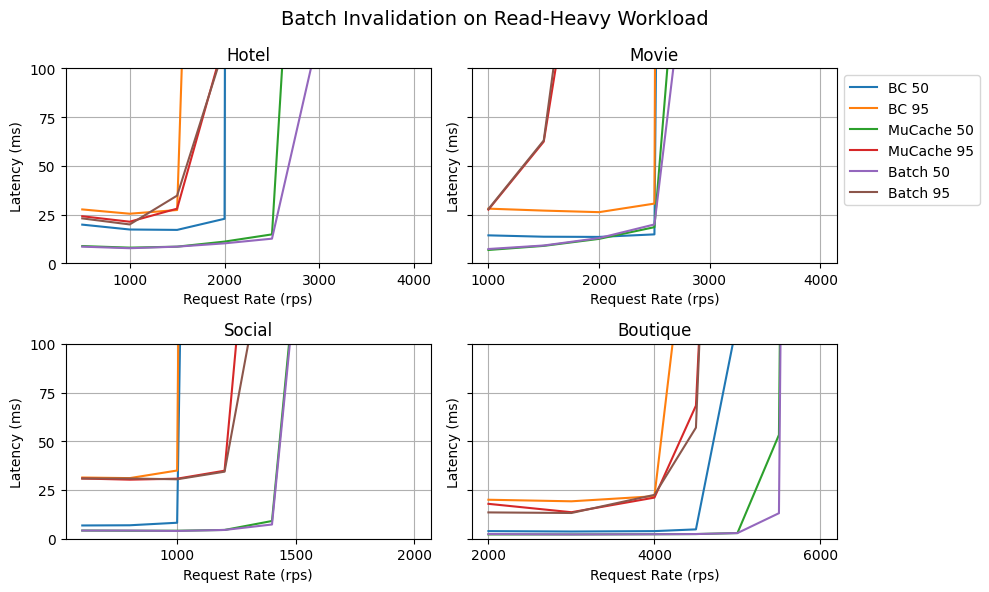

In [53]:
# Original Read-Heavy Workload
hotel_x, hotel_bc = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq.json" )
_, hotel_mucache = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq.json" )
_, hotel_batch = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-1zmq.json" )
movie_x, movie_bc = getStats( "movie-baseline-5000app-12proxy-1zmq.json" )
_, movie_mucache = getStats( "movie-5000app-12proxy-1zmq.json" )
_, movie_batch = getStats( "movie-batch-5000app-12proxy-1zmq.json" )
social_x, social_bc = getStats( "social-baseline-5000app-12proxy-1zmq.json" )
_, social_mucache = getStats( "social-5000app-12proxy-1zmq.json" )
_, social_batch = getStats( "social-batch-5000app-12proxy-1zmq.json" )
boutique_x, boutique_bc = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq.json" )
_, boutique_mucache = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq.json" )
_, boutique_batch = getStats( "boutique-batch-halfProductSize-5000app-12proxy-1zmq.json" )

experiments = [(hotel_x, [hotel_bc["50"], hotel_bc["95"], hotel_mucache["50"], hotel_mucache["95"], hotel_batch["50"], hotel_batch["95"]]), 
               (movie_x, [movie_bc["50"], movie_bc["95"], movie_mucache["50"], movie_mucache["95"], movie_batch["50"], movie_batch["95"]]), 
               (social_x, [social_bc["50"], social_bc["95"], social_mucache["50"], social_mucache["95"], social_batch["50"], social_batch["95"]]), 
               (boutique_x, [boutique_bc["50"], boutique_bc["95"], boutique_mucache["50"], boutique_mucache["95"], boutique_batch["50"], boutique_batch["95"]]),
              ]
labels = ["BC 50", "BC 95", "MuCache 50", "MuCache 95", "Batch 50", "Batch 95"]
titles = ["Hotel", "Movie", "Social", "Boutique"]

plotResults( experiments, labels, "Request Rate (rps)", "Latency (ms)", titles, numRow = 2, figsize=(10,6), suptitle = "Batch Invalidation on Read-Heavy Workload" )


# Speculative Prefetching Results

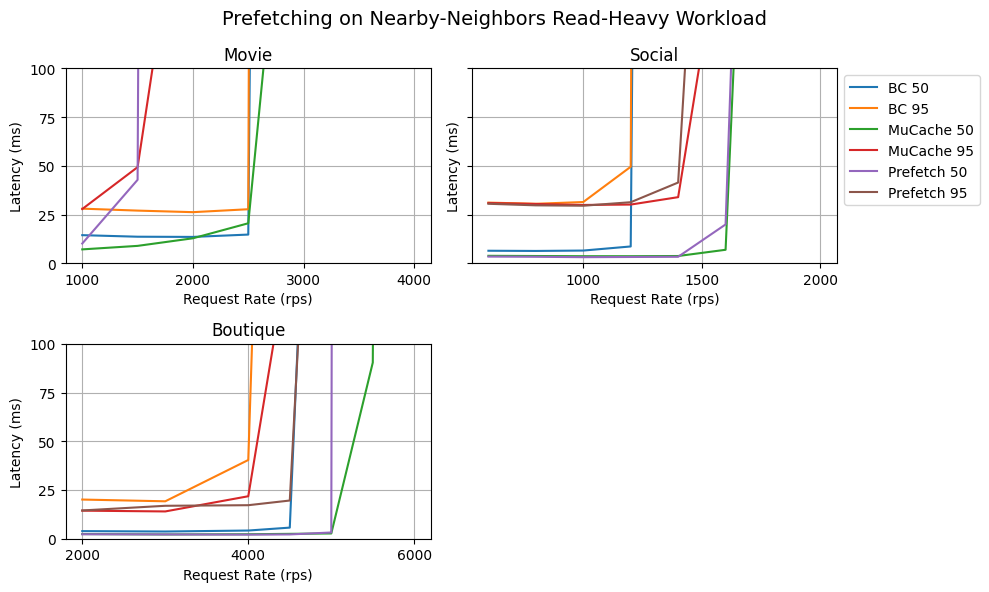

In [16]:
# Nearby Neighbor Read-Heavy
movie_x, movie_bc = getStats( "movie-baseline-nearbyNeighbors-2neighbor-original-context-5000app-12proxy-1zmq-async.json" )
_, movie_mucache = getStats( "movie-nearbyNeighbors-2neighbor-original-context-5000app-12proxy-1zmq-async.json" )
_, movie_prefetch = getStats( "movie-prefetch-nearbyNeighbors-1neighbor-original-context-5000app-12proxy-1zmq-async.json" )
social_x, social_bc = getStats( "social-baseline-nearbyNeighbors-5000app-1zmq-async.json" )
_, social_mucache = getStats( "social-nearbyNeighbors-5000app-1zmq-async.json" )
_, social_prefetch = getStats( "social-prefetch-nearbyNeighbors-5000app-1zmq-async.json" )
boutique_x, boutique_bc = getStats( "boutique-baseline-nearbyUsers-2neighbor-originalContextWith10msTimeOut-halfProductSize-5000app-12proxy-1zmq-async.json" )
_, boutique_mucache = getStats( "boutique-nearbyUsers-2neighbor-originalContextWith10msTimeOut-halfProductSize-5000app-12proxy-1zmq-async.json" )
_, boutique_prefetch = getStats( "boutique-prefetch-nearbyUsers-2neighbor-originalContextWith10msTimeOut-halfProductSize-5000app-12proxy-1zmq-async.json" )

experiments = [(movie_x, [movie_bc["50"], movie_bc["95"], movie_mucache["50"], movie_mucache["95"], movie_prefetch["50"], movie_prefetch["95"]]), 
               (social_x, [social_bc["50"], social_bc["95"], social_mucache["50"], social_mucache["95"], social_prefetch["50"], social_prefetch["95"]]), 
               (boutique_x, [boutique_bc["50"], boutique_bc["95"], boutique_mucache["50"], boutique_mucache["95"], boutique_prefetch["50"], boutique_prefetch["95"]]),
              ]
labels = ["BC 50", "BC 95", "MuCache 50", "MuCache 95", "Prefetch 50", "Prefetch 95"]
titles = ["Movie", "Social", "Boutique"]

plotResults( experiments, labels, "Request Rate (rps)", "Latency (ms)", titles, numRow = 2, figsize=(10,6), suptitle = "Prefetching on Nearby-Neighbors Read-Heavy Workload" )


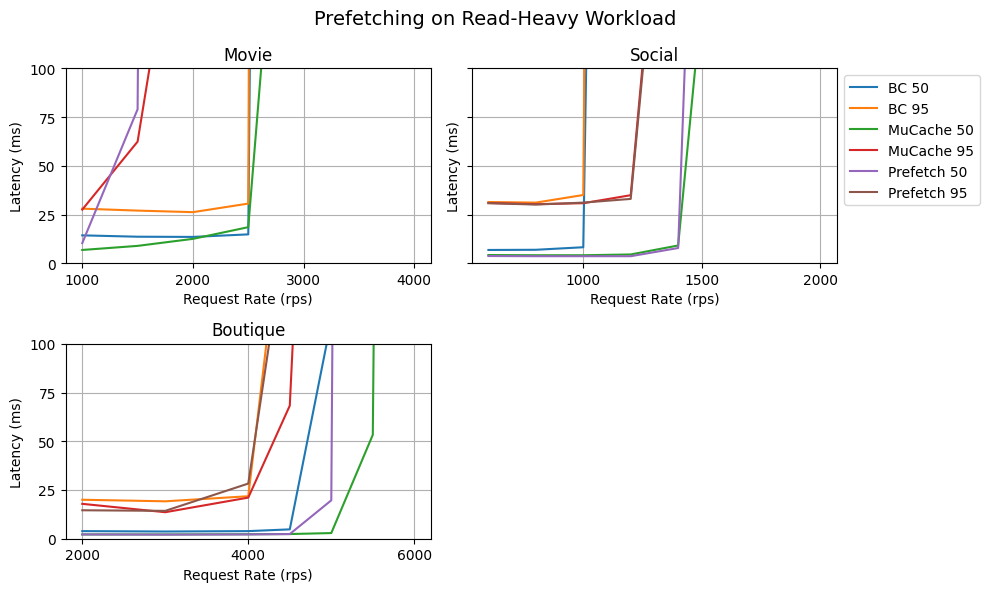

In [57]:
# Original Read-Heavy
# Requires redo of hotel, movie, social, and boutique prefetch on original workload!
# hotel_x, hotel_bc = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq.json" )
# _, hotel_mucache = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq.json" )
# _, hotel_prefetch = getStats( "hotel-prefetch-1000hotelsize-5000app-12proxy-1zmq.json" )
movie_x, movie_bc = getStats( "movie-baseline-5000app-12proxy-1zmq.json" )
_, movie_mucache = getStats( "movie-5000app-12proxy-1zmq.json" )
_, movie_prefetch = getStats( "movie-prefetch-5000app-12proxy-1zmq.json" )
social_x, social_bc = getStats( "social-baseline-5000app-12proxy-1zmq.json" )
_, social_mucache = getStats( "social-5000app-12proxy-1zmq.json" )
_, social_prefetch = getStats( "social-prefetch-5000app-12proxy-1zmq.json" )
boutique_x, boutique_bc = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq.json" )
_, boutique_mucache = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq.json" )
_, boutique_prefetch = getStats( "boutique-prefetch-halfProductSize-5000app-12proxy-1zmq.json" )

experiments = [ 
               (movie_x, [movie_bc["50"], movie_bc["95"], movie_mucache["50"], movie_mucache["95"],movie_prefetch["50"], movie_prefetch["95"]]), 
               (social_x, [social_bc["50"], social_bc["95"], social_mucache["50"], social_mucache["95"],social_prefetch["50"], social_prefetch["95"]]), 
               (boutique_x, [boutique_bc["50"], boutique_bc["95"], boutique_mucache["50"], boutique_mucache["95"],boutique_prefetch["50"], boutique_prefetch["95"]]),
              ]
labels = ["BC 50", "BC 95", "MuCache 50", "MuCache 95", "Prefetch 50", "Prefetch 95"]
titles = ["Movie", "Social", "Boutique"]

plotResults( experiments, labels, "Request Rate (rps)", "Latency (ms)", titles, numRow = 2, figsize=(10,6), suptitle = "Prefetching on Read-Heavy Workload" )
